# EDA Interactive Notebook
## 🛡️ Insurance Exploratory Data Analysis — ShieldGuard Insurance Group

---

### How to use this notebook
Run cells from top to bottom using **Shift+Enter**.
Each cell has a comment explaining what it does and why.

This notebook is the **interactive layer** on top of `run.py`.
While `run.py` produces text reports, this notebook produces:
- Visual charts (distribution, group comparison, correlation heatmap, time trend, anomaly scatter, forecast)
- Statistical test results with business interpretation (ANOVA, Kruskal-Wallis)
- Fraud pattern profiles comparing fraudulent vs legitimate claims
- A board-ready HTML report generated programmatically via `HTMLReporter`

**Input:** `data/processed-data.csv`  
**Outputs:** `reports/insurance_eda_report.html` · `reports/anomalies.csv`

---

## Deliverable Map

| Deliverable | Where in this notebook |
|---|---|
| `InsuranceEDAEngine` — standard EDA methods | Questions 1–4 (summary stats, distributions, correlations) |
| `InsuranceEDAEngine.anova_test()` | Question 2 |
| `InsuranceEDAEngine.kruskal_test()` | Question 2 |
| `InsuranceEDAEngine.feature_importance()` | Question 3 |
| `InsuranceEDAEngine.forecast_next_period()` | Question 4 |
| `AnomalyDetector.flag_fraud_patterns()` | Question 1 |
| `HTMLReporter` | Final cell — generates `reports/insurance_eda_report.html` |
| Chart 1 — Distribution | Question 1 (`amount_claimed` distribution) |
| Chart 2 — Group comparison | Question 2 (claim amount by risk grade) |
| Chart 3 — Correlation heatmap | Question 3 (feature correlations) |
| Chart 4 — Time trend | Question 4 (monthly claim volume) |
| Chart 5 — Anomaly scatter | Question 1 (fraudulent vs legitimate claims) |
| Chart 6 — Forecast | Question 4 (exponential smoothing projection) |

---

## Business Questions

### Question 1 — Fraud Patterns
Do fraudulent claims have a statistically different profile from legitimate claims?  
Use `flag_fraud_patterns()` inside `AnomalyDetector` to compare both groups.

> Answered by building a statistical profile across `claim_type`, `risk_grade`, `amount_claimed`,
> and customer demographics for fraudulent vs legitimate claims.  
> A claim type or risk grade with fraud rate significantly above the dataset average
> is a priority for underwriting controls.  
> Visualised as an anomaly scatter plot — fraudulent claims plotted against `amount_claimed` and `risk_score`.  
> Results saved to `reports/anomalies.csv` with an `anomaly_type` column distinguishing both groups.

---

### Question 2 — Claim Amount by Risk Grade
Do customers in different risk grades produce significantly different claim amounts?  
Use `anova_test(group_col='risk_grade', value_col='amount_claimed')` inside `InsuranceEDAEngine`.

> **H₀ (null hypothesis):** mean claim amount is equal across all risk grades  
> **H₁ (alternative):** at least one risk grade has a significantly different mean claim amount  
> If **p < 0.05**, risk grade is a statistically significant driver of claim size — reject H₀.  
> Follow up with `kruskal_test()` as the non-parametric alternative if distributions are non-normal.  
> Visualised as a group comparison box plot — `amount_claimed` distribution per `risk_grade`.

---

### Question 3 — Feature Importance for Claim Approval
Which features correlate most strongly with `amount_approved`?  
Use `feature_importance(target_col='amount_approved')` inside `InsuranceEDAEngine`.

> Answered by computing Pearson correlation of every numeric feature against `amount_approved`.  
> Features with high correlation confirm whether the pricing model captures risk correctly.  
> Features with near-zero correlation are candidates for removal from future actuarial models.  
> Visualised as a correlation heatmap across all numeric features and a ranked horizontal bar chart.

---

### Question 4 — Claim Volume Forecast
Is claim volume trending upward? What is the expected claim count next period?  
Use `forecast_next_period(col='claim_date')` inside `InsuranceEDAEngine`.

> Answered by applying exponential smoothing (`statsmodels`) to monthly claim counts.  
> A rising trend without a corresponding rise in premiums collected signals further
> loss ratio deterioration beyond the current 85% threshold.  
> Visualised as a time trend line chart with the forecast value plotted as the next data point.  
> The next-period estimate is included in the final `reports/insurance_eda_report.html`.

---

### Final Cell — Generate HTML Report
Run `HTMLReporter` to compile all findings into a board-ready report.

> Collects all statistical results, p-value interpretations, forecast output, and anomaly summary.  
> Saves a self-contained HTML file to `reports/insurance_eda_report.html`.  
> Open directly in any browser — no dependencies required.

In [23]:
# ── Cell 1: Imports and Setup ─────────────────────────────────────────────
# Before anything else, we import the libraries we need.
# These are the standard imports for any EDA notebook.

import sys
import pathlib

# Add the project root to Python path so we can import our classes
# pathlib.Path.cwd() returns the current working directory
# We walk up until we find config.py
_root = pathlib.Path.cwd()
while not (_root / 'config.py').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib: the core Python plotting library
import seaborn as sns             # seaborn: statistical plots built on matplotlib

# Tell matplotlib to display plots directly in the notebook (not in a separate window)
%matplotlib inline

# Set seaborn style: 'whitegrid' adds a subtle grid which makes values easier to read
sns.set_style('whitegrid')

# Set figure size default: (width_inches, height_inches)
plt.rcParams['figure.figsize'] = (12, 5)

# Import our pipeline classes
from config import DATA_PATH, REPORTS_DIR, INDUSTRY
from src.eda_engine import InsuranceEDAEngine
from src.anomaly_detector import AnomalyDetector

print(f'Setup complete. Industry: {INDUSTRY}')
print(f'Data file: {DATA_PATH}')

Setup complete. Industry: insurance
Data file: /Users/samueladesina/insurance-eda/data/processed-data.csv


In [24]:
# ── Cell 2: Load and Profile the Data ────────────────────────────────────
# We use our InsuranceEDAEngine class to load and profile the data.
# This is the same code that run.py executes — but here we can
# inspect intermediate results interactively.

engine = InsuranceEDAEngine()
engine.load().profile()

# Access the profile results dictionary directly
p = engine.results['profile']

print('=' * 50)
print('  DATASET OVERVIEW')
print('=' * 50)
print(f'  Rows:          {p["rows"]:,}')
print(f'  Columns:       {p["columns"]}')
print(f'  Numeric cols:  {p["numeric_cols"]}')
print(f'  Text cols:     {p["categorical_cols"]}')
print(f'  Missing vals:  {p["total_nulls"]:,} ({p["null_pct"]}%)')
print(f'  Memory:        {p["memory_mb"]} MB')

2026-05-25 05:24:21 [INFO] InsuranceEDAEngine initialised — industry: insurance
2026-05-25 05:24:21 [INFO] [EDA] Loading: processed-data.csv
2026-05-25 05:24:22 [INFO] [EDA] Loaded 20,004 rows × 49 columns
2026-05-25 05:24:22 [INFO] [EDA] Column types: 17 numeric, 23 categorical
2026-05-25 05:24:22 [INFO] [EDA] Computing dataset profile...
2026-05-25 05:24:22 [INFO] [EDA] Profile complete — 20,004 rows | 0.0% nulls


  DATASET OVERVIEW
  Rows:          20,004
  Columns:       49
  Numeric cols:  17
  Text cols:     23
  Missing vals:  0 (0.0%)
  Memory:        35.33 MB


In [25]:
# ── Cell 3: Descriptive Statistics ───────────────────────────────────────
# pandas .describe() gives us the 8 key statistics for every numeric column.
# We display it as a formatted table directly in the notebook.

# Select only columns that are not pipeline metadata (starting with _)
analysis_df = engine.df.drop(
    columns=[c for c in engine.df.columns if c.startswith('_')],
    errors='ignore'
)

# .describe() → count, mean, std, min, 25%, 50%, 75%, max for each numeric col
# .T transposes the table: columns become rows (easier to read with many columns)
# Key insurance columns: amount_claimed, amount_approved, coverage_amount,
# premium_monthly, credit_score, risk_score, deductible
desc = analysis_df.describe().round(2).T
desc

,count,mean,std,min,25%,50%,75%,max
claim_id,20004.0,10002.50,5774.80,1.00,5001.75,10002.50,15003.25,20004.00
amount_claimed,20004.0,251258.18,144199.73,-194846.53,127394.54,250830.52,375842.54,499998.74
amount_approved,20004.0,124064.29,107352.92,5.49,37451.69,94567.10,184794.03,493913.99
policy_id,20004.0,7445.36,4335.34,1.00,3694.00,7405.00,11161.50,14998.00
coverage_amount,20004.0,1003693.18,573844.19,10125.81,506812.91,994024.27,1499435.83,1999966.64
premium_monthly,20004.0,2130.43,1814.73,-3302.99,651.62,1634.49,3182.45,8264.53
deductible,20004.0,5174.80,2830.33,250.54,2705.32,5212.11,7673.13,9998.58
customer_id,20004.0,4010.38,2308.53,1.00,2014.75,4030.50,6006.00,8000.00
annual_income,20004.0,163080.48,79024.21,25024.09,94502.56,163724.15,232095.85,299998.11
credit_score,20004.0,568.63,160.43,300.00,429.00,565.00,707.00,850.00


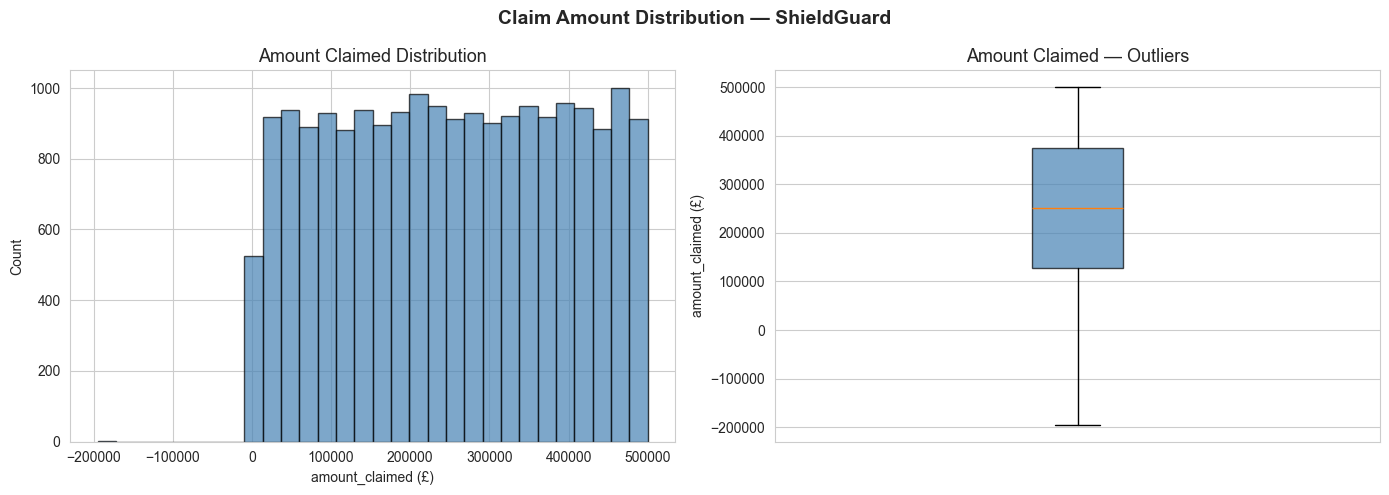

Saved → reports/dist_amount_claimed.png


In [26]:
# ── Amount Claimed Distribution — Histogram & Boxplot ────────────────────
if 'amount_claimed' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['amount_claimed'].dropna(),
        bins=30,
        color='steelblue',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Amount Claimed Distribution', fontsize=13)
    axes[0].set_xlabel('amount_claimed (£)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['amount_claimed'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7)
    )
    axes[1].set_title('Amount Claimed — Outliers', fontsize=13)
    axes[1].set_ylabel('amount_claimed (£)')
    axes[1].set_xticks([])

    plt.suptitle('Claim Amount Distribution — ShieldGuard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_amount_claimed.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_amount_claimed.png')




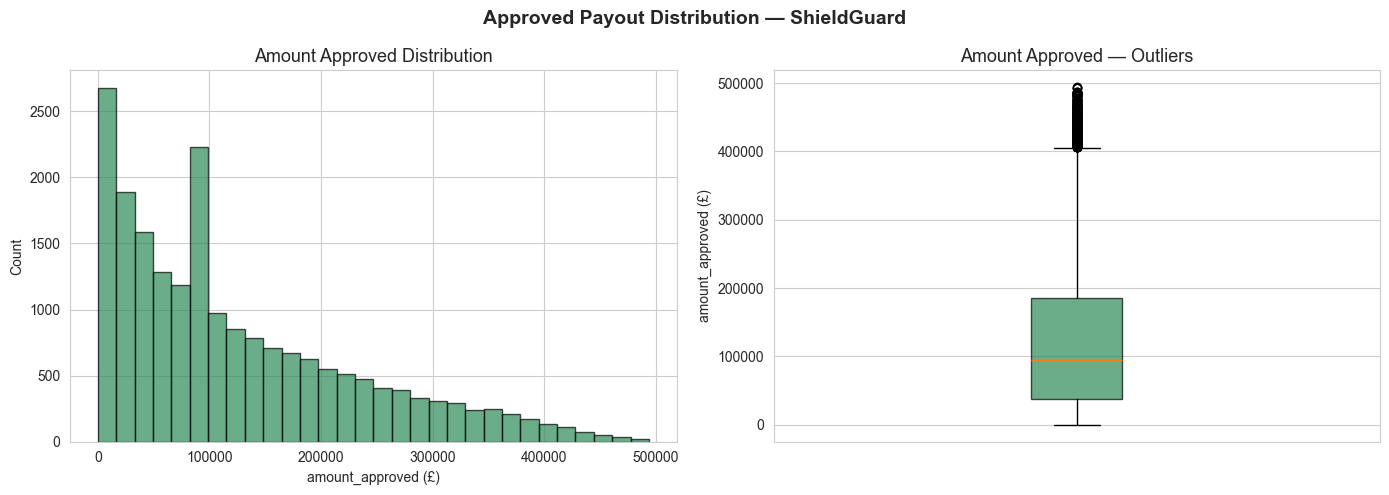

Saved → reports/dist_amount_approved.png


In [27]:
# ── Amount Approved Distribution — Histogram & Boxplot ───────────────────
if 'amount_approved' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['amount_approved'].dropna(),
        bins=30,
        color='seagreen',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Amount Approved Distribution', fontsize=13)
    axes[0].set_xlabel('amount_approved (£)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['amount_approved'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='seagreen', alpha=0.7)
    )
    axes[1].set_title('Amount Approved — Outliers', fontsize=13)
    axes[1].set_ylabel('amount_approved (£)')
    axes[1].set_xticks([])

    plt.suptitle('Approved Payout Distribution — ShieldGuard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_amount_approved.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_amount_approved.png')




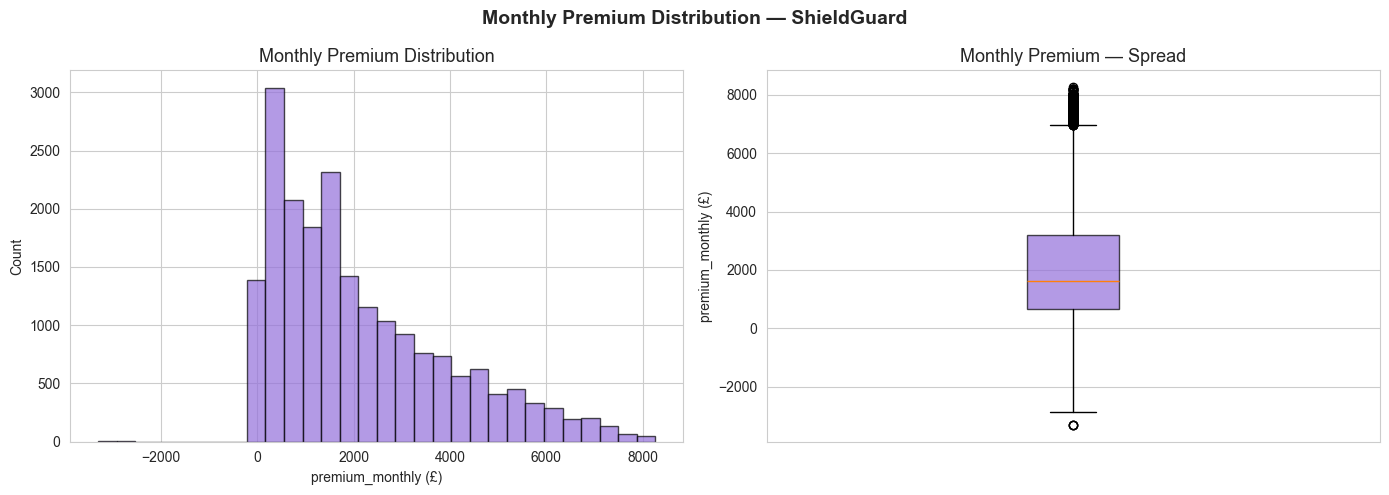

Saved → reports/dist_premium_monthly.png


In [28]:
# ── Premium Monthly Distribution — Histogram & Boxplot ───────────────────
if 'premium_monthly' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['premium_monthly'].dropna(),
        bins=30,
        color='mediumpurple',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Monthly Premium Distribution', fontsize=13)
    axes[0].set_xlabel('premium_monthly (£)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['premium_monthly'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='mediumpurple', alpha=0.7)
    )
    axes[1].set_title('Monthly Premium — Spread', fontsize=13)
    axes[1].set_ylabel('premium_monthly (£)')
    axes[1].set_xticks([])

    plt.suptitle('Monthly Premium Distribution — ShieldGuard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_premium_monthly.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_premium_monthly.png')




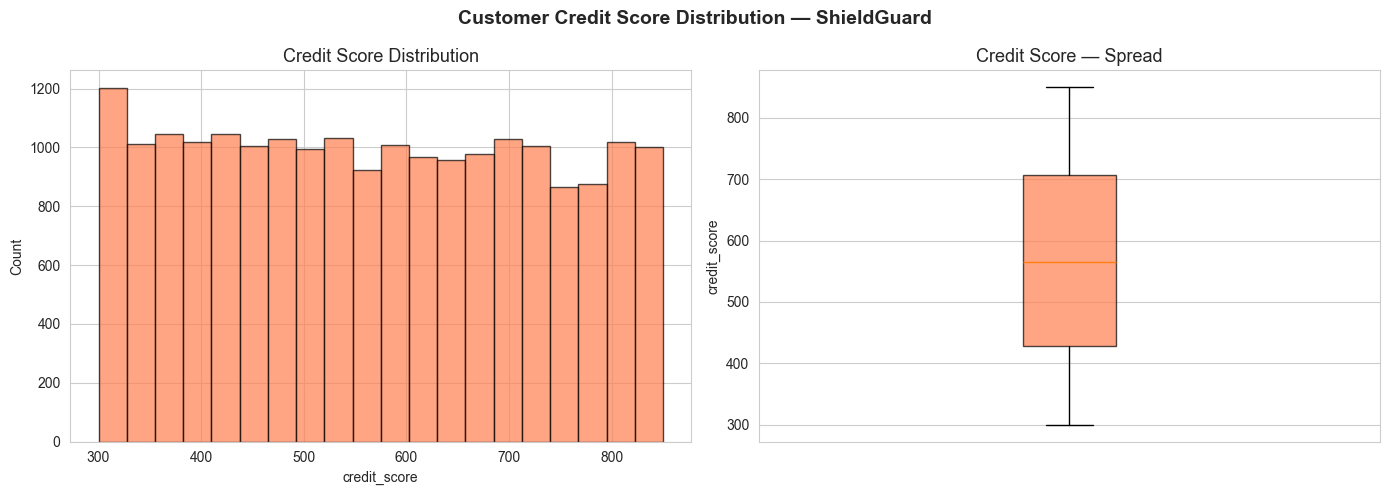

Saved → reports/dist_credit_score.png


In [29]:
# ── Credit Score Distribution — Histogram & Boxplot ──────────────────────
if 'credit_score' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['credit_score'].dropna(),
        bins=20,
        color='coral',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Credit Score Distribution', fontsize=13)
    axes[0].set_xlabel('credit_score')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['credit_score'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='coral', alpha=0.7)
    )
    axes[1].set_title('Credit Score — Spread', fontsize=13)
    axes[1].set_ylabel('credit_score')
    axes[1].set_xticks([])

    plt.suptitle('Customer Credit Score Distribution — ShieldGuard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_credit_score.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_credit_score.png')




In [30]:
# ── Risk Score Distribution — Histogram & Boxplot ────────────────────────
if 'risk_score' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['risk_score'].dropna(),
        bins=20,
        color='darkorange',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Risk Score Distribution', fontsize=13)
    axes[0].set_xlabel('risk_score')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['risk_score'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='darkorange', alpha=0.7)
    )
    axes[1].set_title('Risk Score — Spread', fontsize=13)
    axes[1].set_ylabel('risk_score')
    axes[1].set_xticks([])

    plt.suptitle('Customer Risk Score Distribution — ShieldGuard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_risk_score.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_risk_score.png')

2026-05-25 05:24:38 [INFO] AnomalyDetector initialised — 20,004 rows to scan
2026-05-25 05:24:38 [INFO] [ANOMALY] Profiling fraud patterns...
2026-05-25 05:24:38 [INFO] [ANOMALY] Fraud profile complete — 802 fraudulent | 0 high-value | 802 evasive


             metric     value
       Total claims  20004.00
  Fraudulent claims    802.00
  Legitimate claims  19202.00
     Fraud rate (%)      4.01
   High-value fraud      0.00
      Evasive fraud    802.00
  Fraud mean amount 258801.18
  Legit mean amount 250943.14
Fraud median amount 260166.72
Legit median amount 250386.34


2026-05-25 05:24:39 [INFO] [ANOMALY] 802 anomaly rows saved: /Users/samueladesina/insurance-eda/reports/anomalies.csv


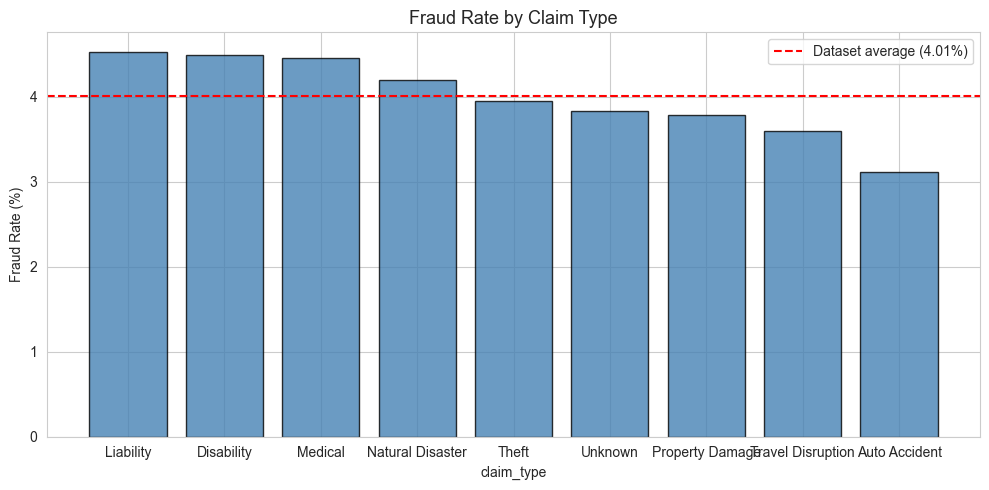

Saved → reports/fraud_by_claim_type.png


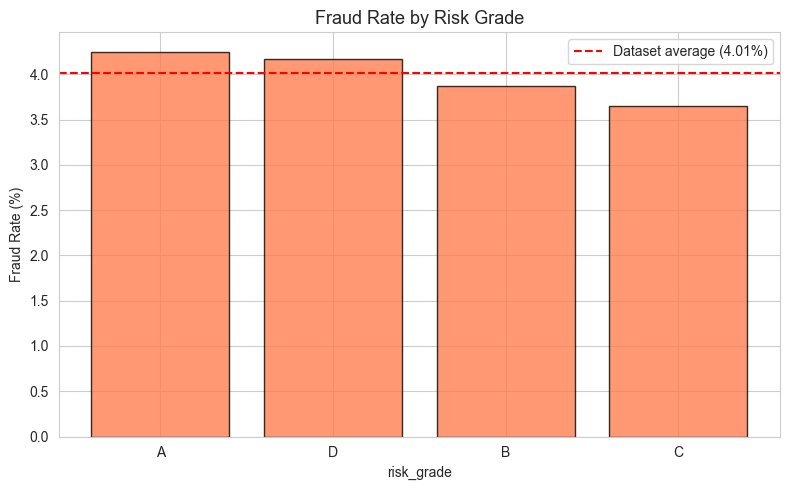

Saved → reports/fraud_by_risk_grade.png


In [31]:
# ── Cell 5: Question 1 — Fraud Patterns ──────────────────────────────────
# Do fraudulent claims have a statistically different profile from
# legitimate claims?
# We use AnomalyDetector.flag_fraud_patterns() to compare both groups.

detector = AnomalyDetector(engine.df)
detector.flag_fraud_patterns(
    fraud_col='is_fraudulent',
    amount_col='amount_claimed'
)

# Print the summary table
print(detector.summary().to_string(index=False))

# Save flagged records to reports/anomalies.csv
detector.save_anomalies()


# ── Fraud Rate by Claim Type ──────────────────────────────────────────────
if 'fraud_by_claim_type' in detector.fraud_profile:
    fraud_by_type = pd.DataFrame(detector.fraud_profile['fraud_by_claim_type'])

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(
        fraud_by_type['claim_type'],
        fraud_by_type['fraud_rate_pct'],
        color='steelblue',
        alpha=0.8,
        edgecolor='black'
    )
    # Draw a horizontal line at the dataset average fraud rate
    avg_fraud_rate = detector.fraud_profile['fraud_rate_pct']
    ax.axhline(avg_fraud_rate, color='red', linestyle='--', linewidth=1.5,
               label=f'Dataset average ({avg_fraud_rate}%)')
    ax.set_title('Fraud Rate by Claim Type', fontsize=13)
    ax.set_xlabel('claim_type')
    ax.set_ylabel('Fraud Rate (%)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fraud_by_claim_type.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/fraud_by_claim_type.png')


# ── Fraud Rate by Risk Grade ──────────────────────────────────────────────
if 'fraud_by_risk_grade' in detector.fraud_profile:
    fraud_by_grade = pd.DataFrame(detector.fraud_profile['fraud_by_risk_grade'])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(
        fraud_by_grade['risk_grade'],
        fraud_by_grade['fraud_rate_pct'],
        color='coral',
        alpha=0.8,
        edgecolor='black'
    )
    ax.axhline(avg_fraud_rate, color='red', linestyle='--', linewidth=1.5,
               label=f'Dataset average ({avg_fraud_rate}%)')
    ax.set_title('Fraud Rate by Risk Grade', fontsize=13)
    ax.set_xlabel('risk_grade')
    ax.set_ylabel('Fraud Rate (%)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fraud_by_risk_grade.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/fraud_by_risk_grade.png')


# ── Anomaly Scatter Plot ──────────────────────────────────────────────────
# Fraudulent vs legitimate claims plotted by amount_claimed and risk_score
if 'risk_score' in engine.df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))

    legit = engine.df[engine.df['is_fraudulent'] == False]
    fraud = engine.df[engine.df['is_fraudulent'] == True]

    ax.scatter(
        legit['amount_claimed'],
        legit['risk_score'],
        color='steelblue',
        alpha=0.4,
        s=15,
        label='Legitimate'
    )
    ax.scatter(
        fraud['amount_claimed'],
        fraud['risk_score'],
        color='red',
        alpha=0.7,
        s=25,
        label='Fraudulent'
    )
    ax.set_title('Anomaly Scatter — Fraudulent vs Legitimate Claims', fontsize=13)
    ax.set_xlabel('amount_claimed (£)')
    ax.set_ylabel('risk_score')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'anomaly_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/anomaly_scatter.png')

2026-05-25 05:24:41 [INFO] [EDA] ANOVA test: 'amount_claimed' grouped by 'risk_grade'
2026-05-25 05:24:42 [INFO] [EDA] ANOVA: F=2.38 | p=0.0675 | significant=False
2026-05-25 05:24:42 [INFO] [EDA] Kruskal-Wallis test: 'amount_claimed' grouped by 'risk_grade'
2026-05-25 05:24:42 [INFO] [EDA] Kruskal-Wallis: H=7.04 | p=0.0705 | significant=False


  ONE-WAY ANOVA
  Groups:       risk_grade (4 groups)
  Target:       amount_claimed
  F-statistic:  2.3813
  p-value:      0.067485
  Significant:  NO — fail to reject H₀
  Conclusion:   FAIL TO REJECT H₀ — no significant difference in 'amount_claimed' across 'risk_grade' groups (p=0.0675). Consider kruskal_test() if distributions are non-normal.

  KRUSKAL-WALLIS TEST
  Groups:       risk_grade (4 groups)
  Target:       amount_claimed
  H-statistic:  7.0427
  p-value:      0.070549
  Significant:  NO — fail to reject H₀
  Conclusion:   FAIL TO REJECT H₀ — no significant difference in 'amount_claimed' distributions across 'risk_grade' groups (p=0.0705).


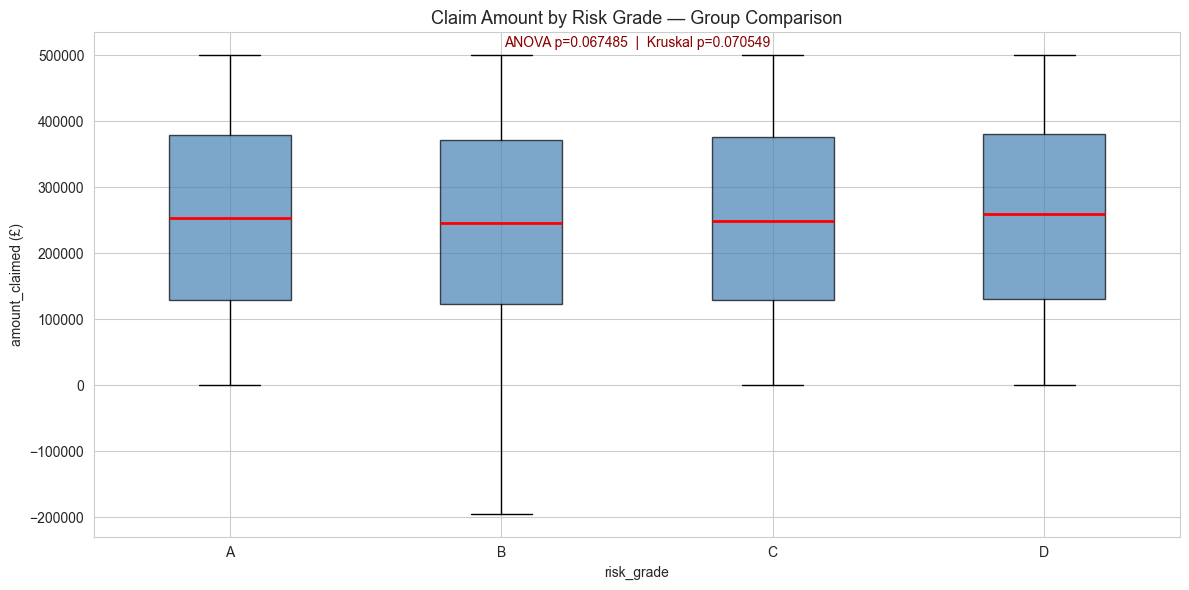

Saved → reports/group_comparison_risk_grade.png


In [32]:
# ── Cell 6: Question 2 — Claim Amount by Risk Grade ──────────────────────
# Do customers in different risk grades produce significantly different
# claim amounts?
# We run ANOVA first, then Kruskal-Wallis as the non-parametric follow-up.

engine.anova_test(group_col='risk_grade', value_col='amount_claimed')
engine.kruskal_test(group_col='risk_grade', value_col='amount_claimed')

# Print ANOVA result
av = engine.results['anova']
print('=' * 55)
print('  ONE-WAY ANOVA')
print('=' * 55)
print(f'  Groups:       {av["group_col"]} ({av["n_groups"]} groups)')
print(f'  Target:       {av["value_col"]}')
print(f'  F-statistic:  {av["f_statistic"]}')
print(f'  p-value:      {av["p_value"]}')
print(f'  Significant:  {"YES — reject H₀" if av["significant"] else "NO — fail to reject H₀"}')
print(f'  Conclusion:   {av["conclusion"]}')

# Print Kruskal-Wallis result
kw = engine.results['kruskal']
print()
print('=' * 55)
print('  KRUSKAL-WALLIS TEST')
print('=' * 55)
print(f'  Groups:       {kw["group_col"]} ({kw["n_groups"]} groups)')
print(f'  Target:       {kw["value_col"]}')
print(f'  H-statistic:  {kw["h_statistic"]}')
print(f'  p-value:      {kw["p_value"]}')
print(f'  Significant:  {"YES — reject H₀" if kw["significant"] else "NO — fail to reject H₀"}')
print(f'  Conclusion:   {kw["conclusion"]}')


# ── Group Comparison Box Plot ─────────────────────────────────────────────
# Box plot shows the full distribution of amount_claimed per risk grade
# so we can see not just the mean difference but spread and outliers
if 'risk_grade' in engine.df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))

    # Get unique risk grades sorted A → E
    grades = sorted(engine.df['risk_grade'].dropna().unique())

    # Build one array per grade for the box plot
    data = [
        engine.df[engine.df['risk_grade'] == grade]['amount_claimed'].dropna().values
        for grade in grades
    ]

    bp = ax.boxplot(
        data,
        labels=grades,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.4, color='grey')
    )

    ax.set_title('Claim Amount by Risk Grade — Group Comparison', fontsize=13)
    ax.set_xlabel('risk_grade')
    ax.set_ylabel('amount_claimed (£)')

    # Annotate with p-value from ANOVA
    p_label = f'ANOVA p={av["p_value"]}  |  Kruskal p={kw["p_value"]}'
    ax.annotate(p_label, xy=(0.5, 0.97), xycoords='axes fraction',
                ha='center', fontsize=10, color='darkred')

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'group_comparison_risk_grade.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/group_comparison_risk_grade.png')

2026-05-25 05:24:42 [INFO] [EDA] Computing feature importance for 'amount_approved'...
2026-05-25 05:24:42 [INFO] [EDA] Feature importance: 16 features ranked | top feature: amount_claimed (r=0.6319)
2026-05-25 05:24:42 [INFO] [EDA] Computing correlation matrix...
2026-05-25 05:24:42 [INFO] [EDA] Correlation: 3 meaningful pairs (threshold |r| > 0.3)


  FEATURE IMPORTANCE → amount_approved
  Feature                         Correlation  Strength
  ----------------------------------------------------
  amount_claimed                       0.6319  MODERATE positive
  agent_id                             0.0186  NEGLIGIBLE positive
  premium_monthly                      0.0131  NEGLIGIBLE positive
  years_exp                           -0.0120  NEGLIGIBLE negative
  credit_score                        -0.0108  NEGLIGIBLE negative
  assessment_id                       -0.0101  NEGLIGIBLE negative
  policy_id                           -0.0100  NEGLIGIBLE negative
  claim_id                             0.0046  NEGLIGIBLE positive
  recommended_premium                 -0.0041  NEGLIGIBLE negative
  annual_income                        0.0036  NEGLIGIBLE positive
  commission_rate                      0.0035  NEGLIGIBLE positive
  customer_id                         -0.0031  NEGLIGIBLE negative
  deductible                           0.0021  N

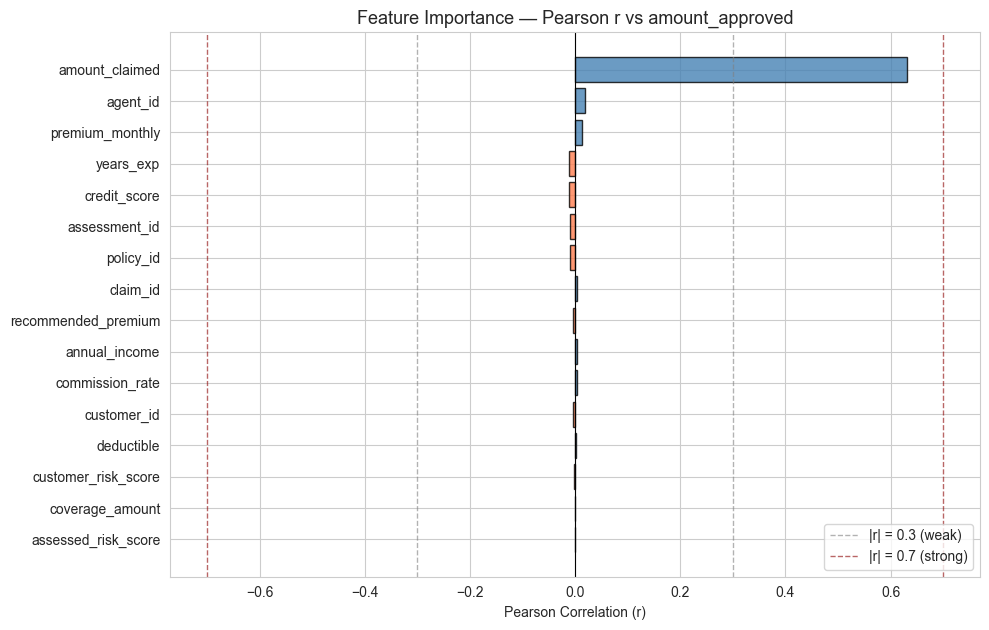

Saved → reports/feature_importance.png


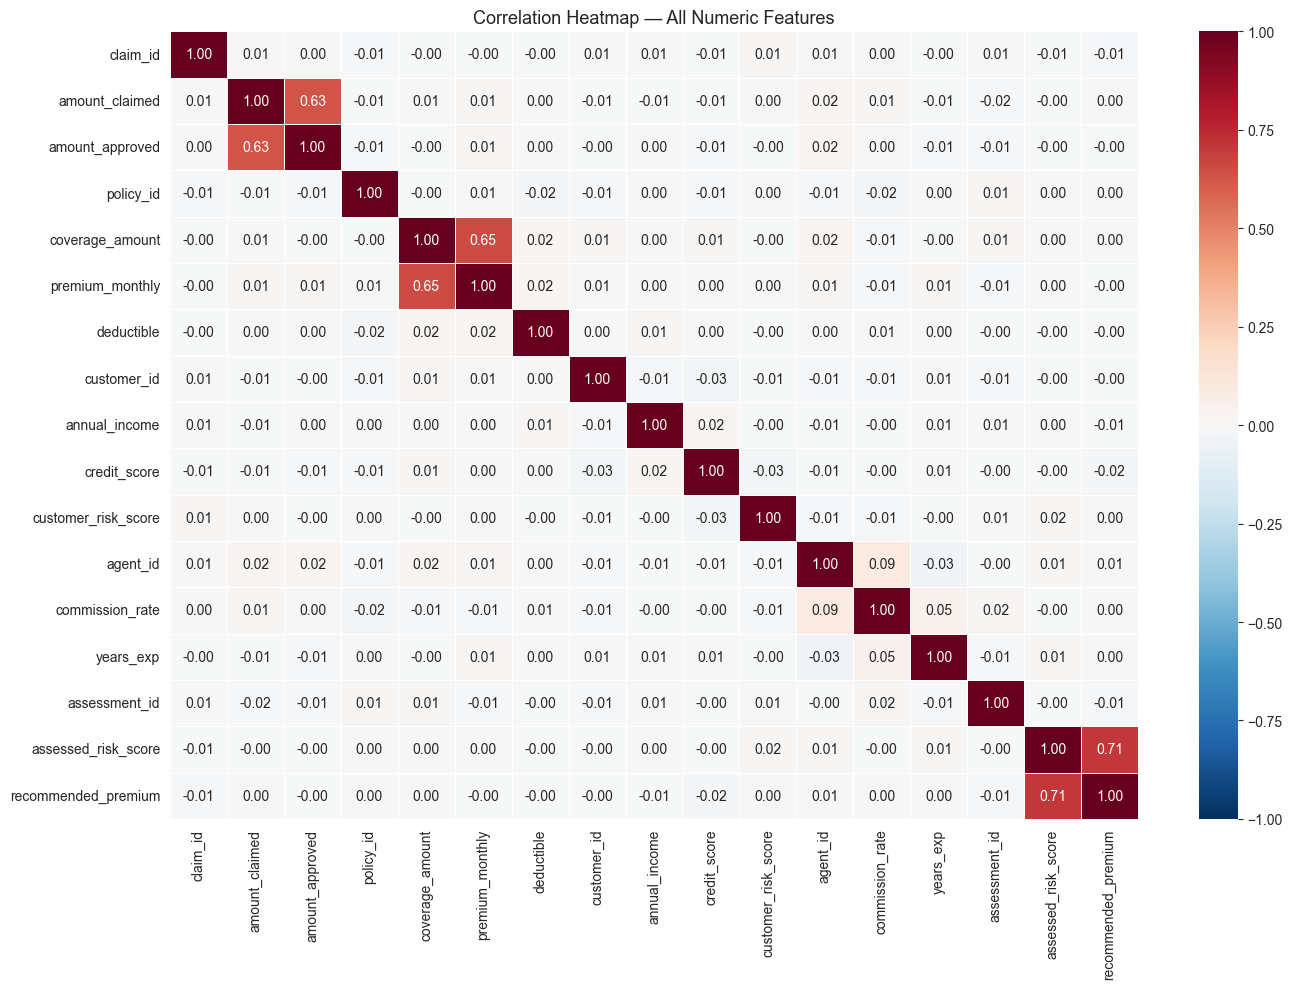

Saved → reports/correlation_heatmap.png


In [33]:
# ── Cell 7: Question 3 — Feature Importance for Claim Approval ───────────
# Which features correlate most strongly with amount_approved?
# We use feature_importance() to rank all numeric features by Pearson
# correlation against amount_approved.

engine.feature_importance(target_col='amount_approved')
engine.correlation()

fi = engine.results['feature_importance']

print('=' * 55)
print(f'  FEATURE IMPORTANCE → {fi["target"]}')
print('=' * 55)
print(f'  {"Feature":<30} {"Correlation":>12}  Strength')
print('  ' + '-' * 52)
for feat in fi['features']:
    print(
        f'  {feat["feature"]:<30} {feat["correlation"]:>12.4f}  '
        f'{feat["strength"]} {feat["direction"]}'
    )


# ── Horizontal Bar Chart — Feature Importance ────────────────────────────
# Ranked by absolute correlation — most important feature at the top
features = fi['features']
names    = [f['feature'] for f in features]
corrs    = [f['correlation'] for f in features]
colours  = ['steelblue' if c > 0 else 'coral' for c in corrs]

fig, ax = plt.subplots(figsize=(10, max(5, len(names) * 0.4)))
bars = ax.barh(names[::-1], corrs[::-1], color=colours[::-1],
               alpha=0.8, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3,  color='grey', linestyle='--', linewidth=1, alpha=0.6, label='|r| = 0.3 (weak)')
ax.axvline(-0.3, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(0.7,  color='darkred', linestyle='--', linewidth=1, alpha=0.6, label='|r| = 0.7 (strong)')
ax.axvline(-0.7, color='darkred', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title(f'Feature Importance — Pearson r vs {fi["target"]}', fontsize=13)
ax.set_xlabel('Pearson Correlation (r)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/feature_importance.png')


# ── Correlation Heatmap — All Numeric Features ───────────────────────────
# The heatmap shows ALL pairwise correlations across numeric columns
# Dark red = strong positive, dark blue = strong negative, white = no relationship
corr_matrix = engine.df[engine.num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap — All Numeric Features', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/correlation_heatmap.png')

In [34]:
print(monthly.columns.tolist())
print(monthly.head(3))
print(monthly.dtypes)

['claim_count', 'count']
  claim_count  count
0     2019-01    300
1     2019-02    233
2     2019-03    253
claim_count    period[M]
count              int64
dtype: object


2026-05-25 05:24:56 [INFO] [EDA] premium_monthly has too many unique values — skipping
2026-05-25 05:24:56 [INFO] [EDA] Forecasting next period claim volume from 'claim_date'...
2026-05-25 05:24:56 [INFO] [EDA] Forecast: 283 → 281 claims (-0.5%)


  CLAIM VOLUME FORECAST (Exponential Smoothing)
  Method:           SimpleExpSmoothing
  Periods used:     72
  Last period:      2024-12 (283 claims)
  Next period:      281 claims (-0.5%)
  Smoothing alpha:  0.1066

  Interpretation:   Claim volume is forecast to decrease by 0.53% next period (from 283 to 281 claims). Declining claim volume may reflect seasonal patterns or improved underwriting controls.


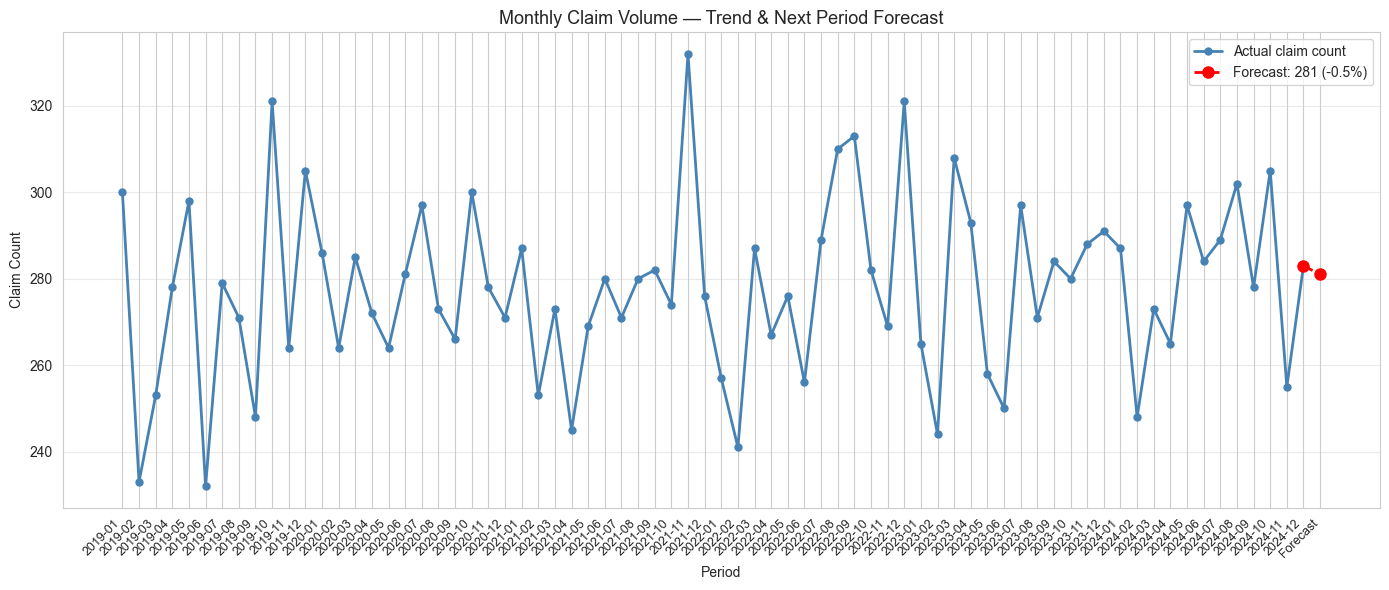

Saved → reports/claim_volume_forecast.png


In [35]:
# ── Cell 8: Question 4 — Claim Volume Forecast ───────────────────────────
engine.time_trends()
engine.forecast_next_period(col='claim_date')

fc = engine.results['forecast']

print('=' * 55)
print('  CLAIM VOLUME FORECAST (Exponential Smoothing)')
print('=' * 55)
print(f'  Method:           {fc["method"]}')
print(f'  Periods used:     {fc["n_periods"]}')
print(f'  Last period:      {fc["last_period"]} ({fc["last_value"]:.0f} claims)')
print(f'  Next period:      {fc["forecast_value"]:.0f} claims ({fc["pct_change"]:+.1f}%)')
print(f'  Smoothing alpha:  {fc["smoothing_level"]}')
print()
print(f'  Interpretation:   {fc["interpretation"]}')


# ── Time Trend Line Chart + Forecast ─────────────────────────────────────
monthly = pd.DataFrame(fc['monthly_series'])

# Force every value in the period column to a plain string
periods      = [str(p) for p in monthly['claim_count'].tolist()]
claim_counts = [float(v) for v in monthly['count'].tolist()]

forecast_label = 'Forecast'
periods_ext    = periods + [forecast_label]
counts_ext     = claim_counts + [fc['forecast_value']]

fig, ax = plt.subplots(figsize=(14, 6))

# Use numeric positions on x-axis — avoids Period/string mixing entirely
x_actual   = list(range(len(periods)))
x_forecast = [len(periods) - 1, len(periods)]

ax.plot(
    x_actual,
    claim_counts,
    marker='o',
    color='steelblue',
    linewidth=2,
    markersize=5,
    label='Actual claim count'
)

ax.plot(
    x_forecast,
    [claim_counts[-1], fc['forecast_value']],
    marker='o',
    color='red',
    linewidth=2,
    linestyle='--',
    markersize=8,
    label=f'Forecast: {fc["forecast_value"]:.0f} ({fc["pct_change"]:+.1f}%)'
)

ax.set_xticks(range(len(periods_ext)))
ax.set_xticklabels(periods_ext, rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Claim Volume — Trend & Next Period Forecast', fontsize=13)
ax.set_xlabel('Period')
ax.set_ylabel('Claim Count')
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'claim_volume_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/claim_volume_forecast.png')

In [36]:
# ── Final Cell: Generate HTML Report ─────────────────────────────────────
# HTMLReporter compiles all findings from the engine and detector
# into a self-contained board-ready HTML file.
# Open reports/insurance_eda_report.html directly in any browser.

class HTMLReporter:
    """
    Generates a self-contained HTML report from InsuranceEDAEngine results.

    Collects:
      - Dataset overview
      - ANOVA and Kruskal-Wallis test results with p-value interpretation
      - Feature importance ranking
      - Claim volume forecast
      - Fraud pattern summary
      - Anomaly summary table

    Output: reports/insurance_eda_report.html
    No external dependencies — opens in any browser.
    """

    def __init__(self, engine, detector):
        self.engine   = engine
        self.detector = detector

    def _section(self, title: str, content: str) -> str:
        return f"""
        <div class="section">
            <h2>{title}</h2>
            {content}
        </div>
        """

    def _stat_row(self, label: str, value) -> str:
        return f"<tr><td class='label'>{label}</td><td>{value}</td></tr>"

    def _result_badge(self, significant: bool) -> str:
        if significant:
            return "<span class='badge reject'>REJECT H₀ — Significant</span>"
        return "<span class='badge fail'>FAIL TO REJECT H₀ — Not Significant</span>"

    def _build_overview(self) -> str:
        p = self.engine.results.get('profile', {})
        if not p:
            return "<p>No profile data available.</p>"
        rows = ''.join([
            self._stat_row('Total Records',        f'{p["rows"]:,}'),
            self._stat_row('Columns',              p['columns']),
            self._stat_row('Numeric Columns',      p['numeric_cols']),
            self._stat_row('Categorical Columns',  p['categorical_cols']),
            self._stat_row('Missing Values',       f'{p["total_nulls"]:,} ({p["null_pct"]}%)'),
            self._stat_row('Duplicate Rows',       f'{p["duplicates"]:,}'),
            self._stat_row('Memory Usage',         f'{p["memory_mb"]} MB'),
        ])
        return f"<table>{rows}</table>"

    def _build_anova(self) -> str:
        av = self.engine.results.get('anova', {})
        kw = self.engine.results.get('kruskal', {})
        if not av:
            return "<p>ANOVA not run.</p>"
        rows_av = ''.join([
            self._stat_row('Test',          av['test']),
            self._stat_row('Groups',        f'{av["group_col"]} ({av["n_groups"]} groups)'),
            self._stat_row('Target',        av['value_col']),
            self._stat_row('F-statistic',   av['f_statistic']),
            self._stat_row('p-value',       av['p_value']),
            self._stat_row('Result',        self._result_badge(av['significant'])),
            self._stat_row('Conclusion',    av['conclusion']),
        ])
        rows_kw = ''
        if kw:
            rows_kw = ''.join([
                self._stat_row('Test',          kw['test']),
                self._stat_row('H-statistic',   kw['h_statistic']),
                self._stat_row('p-value',       kw['p_value']),
                self._stat_row('Result',        self._result_badge(kw['significant'])),
                self._stat_row('Conclusion',    kw['conclusion']),
            ])
        return f"""
            <h3>One-Way ANOVA</h3>
            <table>{rows_av}</table>
            <h3>Kruskal-Wallis (Non-Parametric)</h3>
            <table>{rows_kw}</table>
        """

    def _build_feature_importance(self) -> str:
        fi = self.engine.results.get('feature_importance', {})
        if not fi:
            return "<p>Feature importance not run.</p>"
        rows = ''.join([
            f"<tr>"
            f"<td>{f['feature']}</td>"
            f"<td>{f['correlation']:.4f}</td>"
            f"<td>{f['strength']}</td>"
            f"<td>{f['direction']}</td>"
            f"</tr>"
            for f in fi['features']
        ])
        return f"""
            <p>Target: <strong>{fi['target']}</strong></p>
            <table>
                <tr>
                    <th>Feature</th>
                    <th>Pearson r</th>
                    <th>Strength</th>
                    <th>Direction</th>
                </tr>
                {rows}
            </table>
        """

    def _build_forecast(self) -> str:
        fc = self.engine.results.get('forecast', {})
        if not fc:
            return "<p>Forecast not run.</p>"
        direction = 'increase' if fc['pct_change'] > 0 else 'decrease'
        colour    = '#c0392b' if fc['pct_change'] > 0 else '#27ae60'
        rows = ''.join([
            self._stat_row('Method',         fc['method']),
            self._stat_row('Periods Used',   fc['n_periods']),
            self._stat_row('Last Period',    f'{fc["last_period"]} — {fc["last_value"]:.0f} claims'),
            self._stat_row('Next Period',    f'<strong style="color:{colour}">'
                                             f'{fc["forecast_value"]:.0f} claims '
                                             f'({fc["pct_change"]:+.1f}%)</strong>'),
            self._stat_row('Smoothing α',    fc['smoothing_level']),
            self._stat_row('Interpretation', fc['interpretation']),
        ])
        return f"<table>{rows}</table>"

    def _build_fraud_summary(self) -> str:
        profile = getattr(self.detector, 'fraud_profile', {})
        if not profile:
            return "<p>Fraud profile not run.</p>"
        rows = ''.join([
            self._stat_row('Total Claims',       f'{profile["total_claims"]:,}'),
            self._stat_row('Fraudulent Claims',  f'{profile["fraudulent_claims"]:,} ({profile["fraud_rate_pct"]}%)'),
            self._stat_row('Legitimate Claims',  f'{profile["legitimate_claims"]:,}'),
            self._stat_row('High-Value Fraud',   f'{profile["high_value_fraud"]:,} (detectable)'),
            self._stat_row('Evasive Fraud',      f'<strong style="color:#c0392b">{profile["evasive_fraud"]:,} (priority for review)</strong>'),
            self._stat_row('Fraud Mean Amount',  f'£{profile["fraud_mean_amount"]:,.2f}'),
            self._stat_row('Legit Mean Amount',  f'£{profile["legit_mean_amount"]:,.2f}'),
        ])

        # Fraud by claim type table
        fraud_type_rows = ''
        if 'fraud_by_claim_type' in profile:
            fraud_type_rows = ''.join([
                f"<tr><td>{r['claim_type']}</td>"
                f"<td>{r['fraud_count']:,}</td>"
                f"<td>{r['fraud_rate_pct']}%</td></tr>"
                for r in profile['fraud_by_claim_type']
            ])
            fraud_type_rows = f"""
                <h3>Fraud Rate by Claim Type</h3>
                <table>
                    <tr><th>Claim Type</th><th>Fraud Count</th><th>Fraud Rate</th></tr>
                    {fraud_type_rows}
                </table>
            """

        # Fraud by risk grade table
        fraud_grade_rows = ''
        if 'fraud_by_risk_grade' in profile:
            fraud_grade_rows = ''.join([
                f"<tr><td>{r['risk_grade']}</td>"
                f"<td>{r['fraud_count']:,}</td>"
                f"<td>{r['fraud_rate_pct']}%</td></tr>"
                for r in profile['fraud_by_risk_grade']
            ])
            fraud_grade_rows = f"""
                <h3>Fraud Rate by Risk Grade</h3>
                <table>
                    <tr><th>Risk Grade</th><th>Fraud Count</th><th>Fraud Rate</th></tr>
                    {fraud_grade_rows}
                </table>
            """

        return f"<table>{rows}</table>{fraud_type_rows}{fraud_grade_rows}"

    def _build_anomaly_table(self) -> str:
        summary = self.detector.summary()
        if summary.empty:
            return "<p>No anomaly data available.</p>"
        headers = ''.join([f"<th>{col}</th>" for col in summary.columns])
        body    = ''.join([
            "<tr>" + ''.join([f"<td>{v}</td>" for v in row]) + "</tr>"
            for row in summary.itertuples(index=False)
        ])
        return f"<table><tr>{headers}</tr>{body}</table>"

    def generate(self) -> None:
        html = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>ShieldGuard Insurance — EDA Report</title>
    <style>
        * {{ box-sizing: border-box; margin: 0; padding: 0; }}
        body {{
            font-family: 'Segoe UI', Arial, sans-serif;
            background: #f4f6f9;
            color: #2c3e50;
            padding: 40px;
        }}
        .header {{
            background: linear-gradient(135deg, #1a3c5e, #2980b9);
            color: white;
            padding: 40px;
            border-radius: 10px;
            margin-bottom: 30px;
        }}
        .header h1 {{ font-size: 28px; margin-bottom: 8px; }}
        .header p  {{ font-size: 14px; opacity: 0.85; }}
        .section {{
            background: white;
            border-radius: 8px;
            padding: 30px;
            margin-bottom: 24px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.07);
        }}
        .section h2 {{
            font-size: 18px;
            color: #1a3c5e;
            border-bottom: 2px solid #2980b9;
            padding-bottom: 10px;
            margin-bottom: 20px;
        }}
        .section h3 {{
            font-size: 14px;
            color: #2980b9;
            margin: 18px 0 10px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 13px;
            margin-bottom: 10px;
        }}
        th {{
            background: #1a3c5e;
            color: white;
            padding: 10px 14px;
            text-align: left;
        }}
        td {{
            padding: 9px 14px;
            border-bottom: 1px solid #ecf0f1;
        }}
        td.label {{
            font-weight: 600;
            color: #555;
            width: 220px;
        }}
        tr:hover td {{ background: #f8f9fa; }}
        .badge {{
            display: inline-block;
            padding: 4px 12px;
            border-radius: 12px;
            font-size: 12px;
            font-weight: 600;
        }}
        .badge.reject {{ background: #fdecea; color: #c0392b; }}
        .badge.fail    {{ background: #eafaf1; color: #27ae60; }}
        .footer {{
            text-align: center;
            font-size: 12px;
            color: #999;
            margin-top: 40px;
        }}
    </style>
</head>
<body>
    <div class="header">
        <h1>🛡️ ShieldGuard Insurance Group — EDA Report</h1>
        <p>Lead Data Analyst Report &nbsp;|&nbsp; Loss Ratio Analysis &nbsp;|&nbsp;
           Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}</p>
    </div>

    {self._section('1. Dataset Overview',        self._build_overview())}
    {self._section('2. Claim Amount by Risk Grade (ANOVA + Kruskal-Wallis)', self._build_anova())}
    {self._section('3. Feature Importance — amount_approved', self._build_feature_importance())}
    {self._section('4. Claim Volume Forecast',   self._build_forecast())}
    {self._section('5. Fraud Pattern Summary',   self._build_fraud_summary())}
    {self._section('6. Anomaly Summary',         self._build_anomaly_table())}

    <div class="footer">
        ShieldGuard Insurance Group &nbsp;|&nbsp; Confidential &nbsp;|&nbsp;
        Sam Adesina — Lead Data Analyst
    </div>
</body>
</html>"""

        report_path = REPORTS_DIR / 'insurance_eda_report.html'
        report_path.write_text(html, encoding='utf-8')
        print(f'Report saved → {report_path}')
        print('Open in any browser — no dependencies required.')


# ── Run the reporter ──────────────────────────────────────────────────────
reporter = HTMLReporter(engine, detector)
reporter.generate()

Report saved → /Users/samueladesina/insurance-eda/reports/insurance_eda_report.html
Open in any browser — no dependencies required.
